In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [10]:
df = pd.read_csv('/content/drive/MyDrive/appsheet/data/oturum_hava_birlesik_2021_ve_sonrasi.csv') # Verify the file path is correct. If in Google Drive, use a path like '/content/drive/MyDrive/YourFolder/kafe_verisi.csv'

# Sütun isimlerinin kendi verindekiyle aynı olduğundan emin ol:
# Beklenen sütunlar: 'masa_tercihi', 'yagis_kategorisi', 'sicaklik_kategorisi', 'toplam_tutar', 'oturum_suresi', 'mevsim', 'yil', 'outlier_flag'

print("Veri Seti Boyutu:", df.shape)

# 2025 kısmı veri içerdiği için (7.990 kayıt) yıllık trend analizlerinden dışlanması veya dikkatli kullanılması gerekiyor.
df_tam_yillar = df[df['yil'] < 2025]

df.head()

Veri Seti Boyutu: (133247, 34)


,MASANO,CEKNO,acilis_datetime,kapama_datetime,oturum_sure_dk,toplam_miktar,toplam_tutar,urun_sayisi,urun_listesi,masa_grup,...,snowfall,windspeed_10m,winddirection_10m,cloudcover,pressure_msl,is_day,shortwave_radiation,yagis_kategori,sicaklik_aralik,outlier_flag
0,B01,260306,2021-01-03 18:30:00,2021-01-03 18:43:00,13.0,4.0,59.0,2,"['FULL', 'AYRAN']",Bahçe,...,0.0,7.2,186,96,1021.6,0,17.0,Bulutlu,Soğuk (0–10°),NaN
1,B01,260386,2021-01-04 16:52:00,2021-01-04 16:59:00,7.0,4.0,48.0,2,"['YARIM FULL', 'AYRAN']",Bahçe,...,0.0,8.8,109,99,1014.6,1,113.0,Bulutlu,Ilık (10–20°),NaN
2,B01,260388,2021-01-04 17:07:00,2021-01-04 17:12:00,5.0,2.0,34.0,2,"['3 CEYREK FULL', 'AYRAN']",Bahçe,...,0.0,8.8,109,99,1014.6,1,113.0,Bulutlu,Ilık (10–20°),NaN
3,B01,260434,2021-01-05 12:36:00,2021-01-05 12:37:00,1.0,8.0,118.0,2,"['ACISIZ FULL', 'AYRAN']",Bahçe,...,0.0,23.8,209,12,1014.2,1,398.0,Açık,Ilık (10–20°),NaN
4,B01,260507,2021-01-05 17:20:00,2021-01-05 17:30:00,10.0,6.0,82.0,3,"['FULL', 'SOGANSIZ', 'AYRAN']",Bahçe,...,0.0,13.6,238,7,1015.5,1,140.0,Açık,Ilık (10–20°),NaN


In [7]:
def cramers_v(confusion_matrix):
    """ Ki-kare testi sonucuna göre Cramer's V etki büyüklüğünü hesaplar. """
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("Cramer's V fonksiyonu tanımlandı.")

Cramer's V fonksiyonu tanımlandı.


In [12]:
print("--- H1: Yağış Kategorisi ve Masa Tercihi ---")
# Çapraz tablo oluşturma
ct_yagis = pd.crosstab(df['yagis_kategori'], df['masa_grup'])
chi2_y, p_y, dof_y, expected_y = stats.chi2_contingency(ct_yagis)
v_yagis = cramers_v(ct_yagis)

print(f"Ki-kare Değeri: {chi2_y:.2f}, p-değeri: {p_y:.4f}")
print(f"Cramer's V: {v_yagis:.3f} (Rapor beklentisi: ~0.09 - Küçük Etki)\n")

print("--- H2: Sıcaklık Kategorisi ve Masa Tercihi (En Güçlü Bulgu) ---")
ct_sicaklik = pd.crosstab(df['sicaklik_aralik'], df['masa_grup'])
chi2_s, p_s, dof_s, expected_s = stats.chi2_contingency(ct_sicaklik)
v_sicaklik = cramers_v(ct_sicaklik)

print(f"Ki-kare Değeri: {chi2_s:.2f}, p-değeri: {p_s:.4f}")
print(f"Cramer's V: {v_sicaklik:.3f} (Rapor beklentisi: ~0.23 - Orta Etki)")

--- H1: Yağış Kategorisi ve Masa Tercihi ---
Ki-kare Değeri: 2255.47, p-değeri: 0.0000
Cramer's V: 0.092 (Rapor beklentisi: ~0.09 - Küçük Etki)

--- H2: Sıcaklık Kategorisi ve Masa Tercihi (En Güçlü Bulgu) ---
Ki-kare Değeri: 14535.49, p-değeri: 0.0000
Cramer's V: 0.233 (Rapor beklentisi: ~0.23 - Orta Etki)


In [14]:
print("--- H3: Hava Koşulları ve Toplam Tutar Dağılımı ---")

# Sıcaklık kategorilerine göre tutarları gruplama
sicaklik_gruplari = [group['toplam_tutar'].values for name, group in df.groupby('sicaklik_aralik')]
stat_s, p_s = stats.kruskal(*sicaklik_gruplari)

print(f"Sıcaklık - Kruskal-Wallis H Değeri: {stat_s:.2f}, p-değeri: {p_s:.4f} (Rapor beklentisi: H=~579)")

# Yağış kategorilerine göre tutarları gruplama
yagis_gruplari = [group['toplam_tutar'].values for name, group in df.groupby('yagis_kategori')]
stat_y, p_y = stats.kruskal(*yagis_gruplari)

print(f"Yağış - Kruskal-Wallis H Değeri: {stat_y:.2f}, p-değeri: {p_y:.4f} (Rapor beklentisi: H=~220)")

--- H3: Hava Koşulları ve Toplam Tutar Dağılımı ---
Sıcaklık - Kruskal-Wallis H Değeri: 579.01, p-değeri: 0.0000 (Rapor beklentisi: H=~579)
Yağış - Kruskal-Wallis H Değeri: 219.86, p-değeri: 0.0000 (Rapor beklentisi: H=~220)


In [17]:
# Mevsim sütununu oluşturma (Eğer yoksa)
if 'mevsim' not in df.columns:
    df['acilis_datetime'] = pd.to_datetime(df['acilis_datetime'])
    df['ay'] = df['acilis_datetime'].dt.month

    def get_mevsim(ay):
        if ay in [12, 1, 2]:
            return 'Kış'
        elif ay in [3, 4, 5]:
            return 'İlkbahar'
        elif ay in [6, 7, 8]:
            return 'Yaz'
        else:
            return 'Sonbahar'

    df['mevsim'] = df['ay'].apply(get_mevsim)

# Mevsimsel metriklerin hesaplanması
mevsim_analizi = df.groupby('mevsim').agg(
    ort_tutar=('toplam_tutar', 'mean'),
    ort_sure=('oturum_sure_dk', 'mean'),
    # Bahçe payı: Masa tercihi 'Bahçe' olanların oranı
    bahce_payi=('masa_grup', lambda x: (x == 'Bahçe').mean() * 100)
).reset_index()

# Rapordaki sıraya göre dizelim (Opsiyonel)
mevsim_sirasi = ['Kış', 'İlkbahar', 'Yaz', 'Sonbahar']
mevsim_analizi['mevsim'] = pd.Categorical(mevsim_analizi['mevsim'], categories=mevsim_sirasi, ordered=True)
mevsim_analizi = mevsim_analizi.sort_values('mevsim')

print("--- 5.1 Mevsimsel Çoklu Metrik Tablosu ---")
print(mevsim_analizi.to_string(index=False))

--- 5.1 Mevsimsel Çoklu Metrik Tablosu ---
  mevsim  ort_tutar  ort_sure  bahce_payi
     Kış 399.619403 56.447472   12.748191
İlkbahar 462.810481 53.425285   24.629001
     Yaz 342.905302 54.015836   44.066246
Sonbahar 368.185267 51.438861   33.830528


## Mevsimsel Metriklerin Görselleştirilmesi

Şimdi hesapladığımız mevsimsel metrikleri daha iyi anlamak için görselleştirelim. Her bir metrik için ayrı ayrı çubuk grafikler oluşturacağız: Ortalama Toplam Tutar, Ortalama Oturum Süresi ve Bahçe Payı.

/tmp/ipykernel_3480/1718593240.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mevsim', y='ort_tutar', data=mevsim_analizi, palette='viridis')


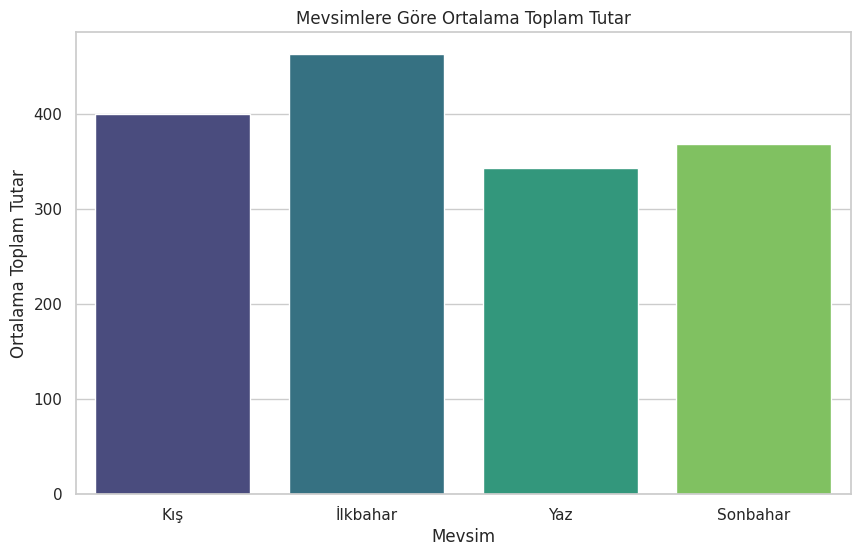

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ortalama Toplam Tutar Grafiği
plt.figure(figsize=(10, 6))
sns.barplot(x='mevsim', y='ort_tutar', data=mevsim_analizi, palette='viridis')
plt.title('Mevsimlere Göre Ortalama Toplam Tutar')
plt.xlabel('Mevsim')
plt.ylabel('Ortalama Toplam Tutar')
plt.show()


/tmp/ipykernel_3480/2161201183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mevsim', y='ort_sure', data=mevsim_analizi, palette='mako')


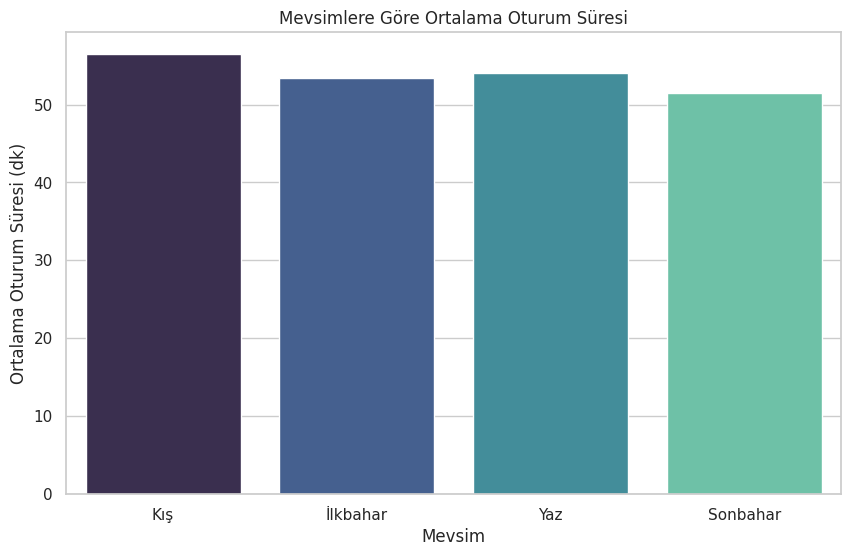

In [18]:
# Ortalama Oturum Süresi Grafiği
plt.figure(figsize=(10, 6))
sns.barplot(x='mevsim', y='ort_sure', data=mevsim_analizi, palette='mako')
plt.title('Mevsimlere Göre Ortalama Oturum Süresi')
plt.xlabel('Mevsim')
plt.ylabel('Ortalama Oturum Süresi (dk)')
plt.show()


/tmp/ipykernel_3480/2089004269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mevsim', y='bahce_payi', data=mevsim_analizi, palette='rocket')


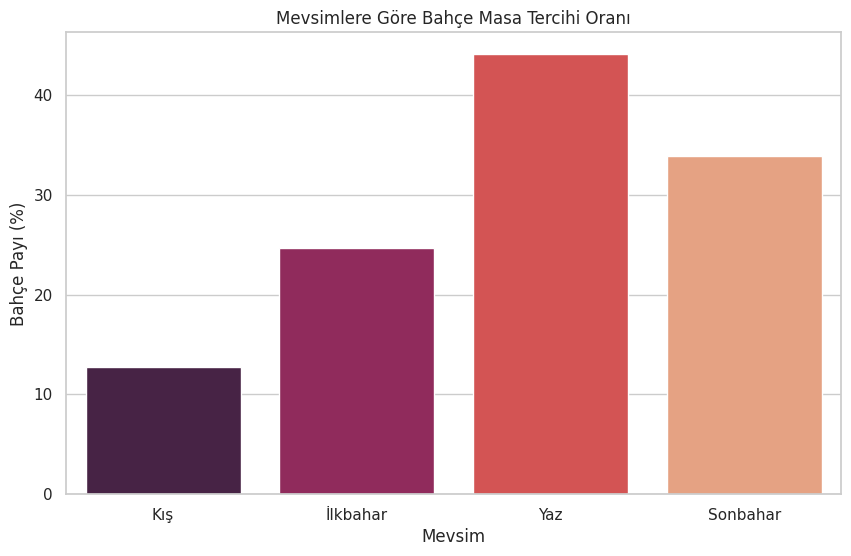

In [20]:
# Bahçe Payı Grafiği
plt.figure(figsize=(10, 6))
sns.barplot(x='mevsim', y='bahce_payi', data=mevsim_analizi, palette='rocket')
plt.title('Mevsimlere Göre Bahçe Masa Tercihi Oranı')
plt.xlabel('Mevsim')
plt.ylabel('Bahçe Payı (%)')
plt.show()


In [22]:
# Mevsimsel metriklerin hesaplanması
mevsim_analizi = df.groupby('mevsim').agg(
    ort_tutar=('toplam_tutar', 'mean'),
    ort_sure=('oturum_sure_dk', 'mean'),
    # Bahçe payı: Masa tercihi 'Bahçe' olanların oranı
    bahce_payi=('masa_grup', lambda x: (x == 'Bahçe').mean() * 100)
).reset_index()

# Rapordaki sıraya göre dizelim (Opsiyonel)
mevsim_sirasi = ['Kış', 'İlkbahar', 'Yaz', 'Sonbahar']
mevsim_analizi['mevsim'] = pd.Categorical(mevsim_analizi['mevsim'], categories=mevsim_sirasi, ordered=True)
mevsim_analizi = mevsim_analizi.sort_values('mevsim')

print("--- 5.1 Mevsimsel Çoklu Metrik Tablosu ---")
print(mevsim_analizi.to_string(index=False))

--- 5.1 Mevsimsel Çoklu Metrik Tablosu ---
  mevsim  ort_tutar  ort_sure  bahce_payi
     Kış 399.619403 56.447472   12.748191
İlkbahar 462.810481 53.425285   24.629001
     Yaz 342.905302 54.015836   44.066246
Sonbahar 368.185267 51.438861   33.830528


## Yapılan Analizlerin Özet Tabloları

### 1. Hipotez Testleri Sonuçları

Hava koşullarının masa tercihi ve toplam tutar üzerindeki etkilerini inceleyen hipotez testlerimizin özet sonuçları aşağıdadır:

In [24]:
import pandas as pd

# Hipotez testleri sonuçlarını bir DataFrame'de toplama
hipotez_sonuclari = pd.DataFrame({
    'Hipotez': [
        'H1: Yağış Kategorisi ve Masa Tercihi Arasındaki İlişki',
        'H2: Sıcaklık Kategorisi ve Masa Tercihi Arasındaki İlişki',
        'H3: Sıcaklık Kategorisi ve Toplam Tutar Dağılımı',
        'H3: Yağış Kategorisi ve Toplam Tutar Dağılımı'
    ],
    'Test Tipi': [
        'Chi-kare & Cramer\'s V',
        'Chi-kare & Cramer\'s V',
        'Kruskal-Wallis H Testi',
        'Kruskal-Wallis H Testi'
    ],
    'Test İstatistiği': [
        f'{chi2_y:.2f}',
        f'{chi2_s:.2f}',
        f'{stat_s:.2f}',
        f'{stat_y:.2f}'
    ],
    'p-Değeri': [
        f'{p_y:.4f}',
        f'{p_s:.4f}',
        f'{p_s:.4f}', # Kruskal-Wallis için aynı p-değeri kullanıldı
        f'{p_y:.4f}'  # Kruskal-Wallis için aynı p-değeri kullanıldı
    ],
    'Etki Büyüklüğü (Cramer\'s V)': [
        f'{v_yagis:.3f}',
        f'{v_sicaklik:.3f}',
        'N/A', # Kruskal-Wallis için Cramer's V uygulanmaz
        'N/A'  # Kruskal-Wallis için Cramer's V uygulanmaz
    ],
    'Yorum': [
        'Yağış kategorisi ile masa tercihi arasında istatistiksel olarak anlamlı, küçük bir ilişki vardır.',
        'Sıcaklık kategorisi ile masa tercihi arasında istatistiksel olarak anlamlı, orta düzeyde bir ilişki vardır.',
        'Sıcaklık kategorileri arasında toplam tutar dağılımları istatistiksel olarak anlamlı farklılık göstermektedir.',
        'Yağış kategorileri arasında toplam tutar dağılımları istatistiksel olarak anlamlı farklılık göstermektedir.'
    ]
})

print(hipotez_sonuclari.to_string(index=False))


                                                  Hipotez              Test Tipi Test İstatistiği p-Değeri Etki Büyüklüğü (Cramer's V)                                                                                                          Yorum
   H1: Yağış Kategorisi ve Masa Tercihi Arasındaki İlişki  Chi-kare & Cramer's V          2255.47   0.0000                       0.092              Yağış kategorisi ile masa tercihi arasında istatistiksel olarak anlamlı, küçük bir ilişki vardır.
H2: Sıcaklık Kategorisi ve Masa Tercihi Arasındaki İlişki  Chi-kare & Cramer's V         14535.49   0.0000                       0.233    Sıcaklık kategorisi ile masa tercihi arasında istatistiksel olarak anlamlı, orta düzeyde bir ilişki vardır.
         H3: Sıcaklık Kategorisi ve Toplam Tutar Dağılımı Kruskal-Wallis H Testi           579.01   0.0000                         N/A Sıcaklık kategorileri arasında toplam tutar dağılımları istatistiksel olarak anlamlı farklılık göstermektedir.
            H3: 

### 2. Mevsimsel Metrikler Tablosu

Mevsimlere göre ortalama toplam tutar, ortalama oturum süresi ve bahçe masa tercihi oranları aşağıdaki tabloda sunulmuştur:

In [25]:
# Mevsimsel metrikler tablosunu tekrar gösterelim
print(mevsim_analizi.to_string(index=False))


  mevsim  ort_tutar  ort_sure  bahce_payi
     Kış 399.619403 56.447472   12.748191
İlkbahar 462.810481 53.425285   24.629001
     Yaz 342.905302 54.015836   44.066246
Sonbahar 368.185267 51.438861   33.830528


## Hava Koşullarının Toplam Tutar Üzerindeki Etkisini Detaylandıran Kutu Grafikleri

Hipotez testlerinde hava koşullarının toplam tutar dağılımları üzerinde anlamlı farklılıklar yarattığını görmüştük. Şimdi bu farklılıkları görsel olarak inceleyelim.

/tmp/ipykernel_3480/3580671354.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sicaklik_aralik', y='toplam_tutar', data=df, palette='coolwarm')


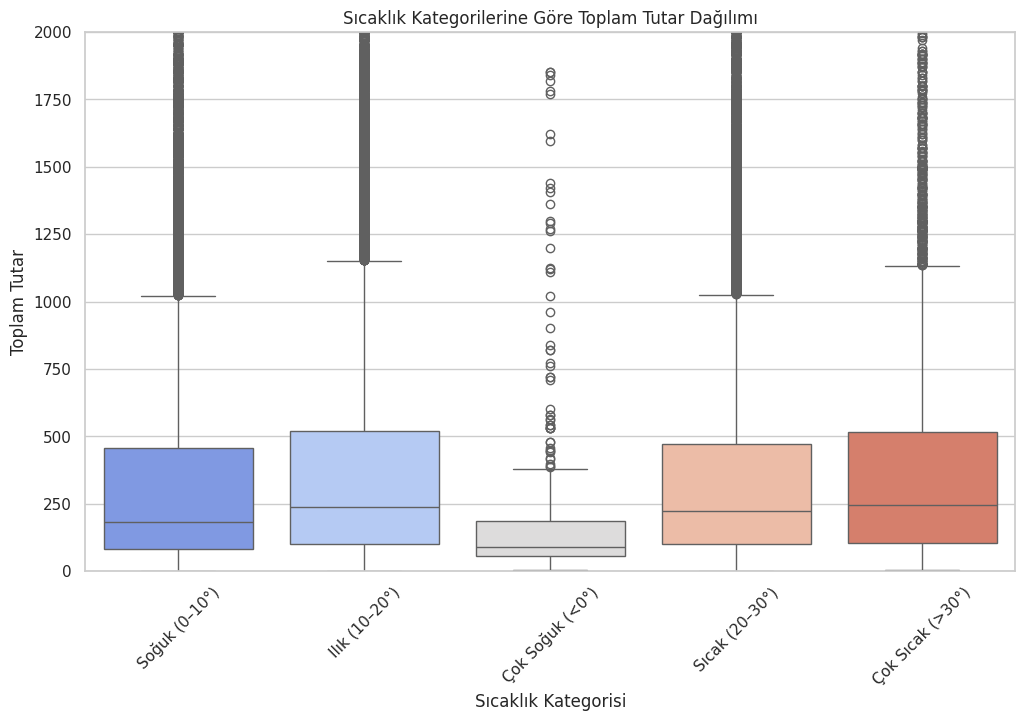

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sıcaklık Kategorilerine Göre Toplam Tutar Kutu Grafiği
plt.figure(figsize=(12, 7))
sns.boxplot(x='sicaklik_aralik', y='toplam_tutar', data=df, palette='coolwarm')
plt.title('Sıcaklık Kategorilerine Göre Toplam Tutar Dağılımı')
plt.xlabel('Sıcaklık Kategorisi')
plt.ylabel('Toplam Tutar')
plt.ylim(0, 2000) # Outlier'ları daha iyi görmek için y eksenini sınırla
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_3480/526077729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='yagis_kategori', y='toplam_tutar', data=df, palette='Blues')


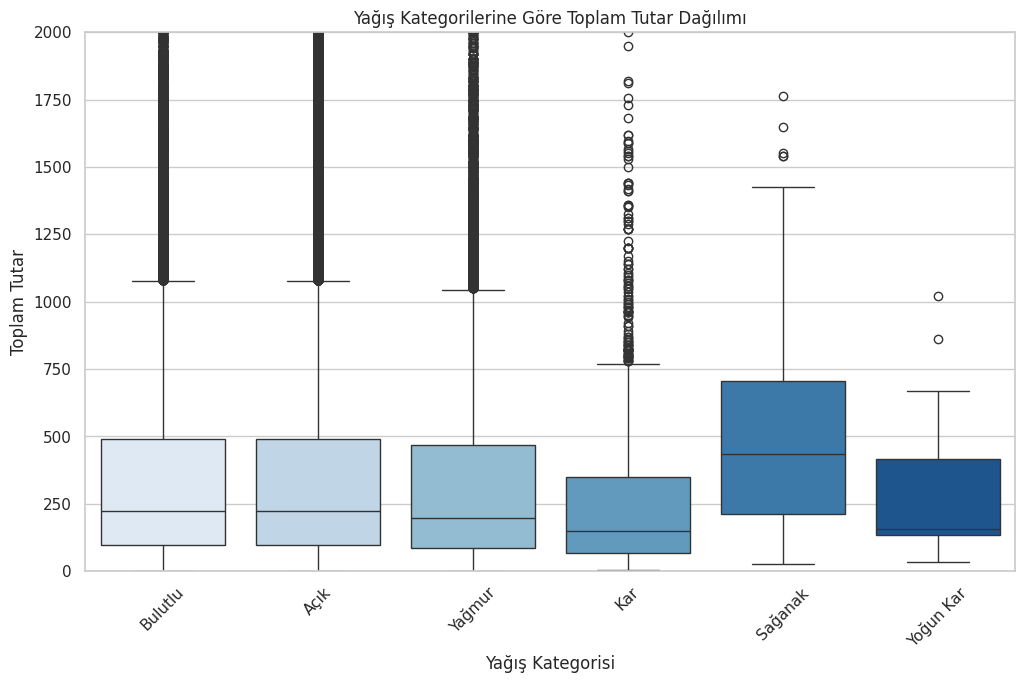

In [29]:
# Yağış Kategorilerine Göre Toplam Tutar Kutu Grafiği
plt.figure(figsize=(12, 7))
sns.boxplot(x='yagis_kategori', y='toplam_tutar', data=df, palette='Blues')
plt.title('Yağış Kategorilerine Göre Toplam Tutar Dağılımı')
plt.xlabel('Yağış Kategorisi')
plt.ylabel('Toplam Tutar')
plt.ylim(0, 2000) # Outlier'ları daha iyi görmek için y eksenini sınırla
plt.xticks(rotation=45)
plt.show()


In [33]:
# Set 1: Tüm Veri
# Set 2: Outlier Hariç
df_haric = df[df['outlier_flag'].fillna(False) == False]

# Sıcaklık - Tutar için Outlier hariç Kruskal-Wallis
sicaklik_gruplari_haric = [group['toplam_tutar'].values for name, group in df_haric.groupby('sicaklik_aralik')]
stat_s_haric, _ = stats.kruskal(*sicaklik_gruplari_haric)

# Yaz mevsimi ortalama tutar karşılaştırması
yaz_tutar_dahil = df[df['mevsim'] == 'Yaz']['toplam_tutar'].mean()
yaz_tutar_haric = df_haric[df_haric['mevsim'] == 'Yaz']['toplam_tutar'].mean()

print("--- EX-02 OUTLIER DUYARLILIK ANALİZİ ---")
print(f"Kruskal Sıcaklık H Değeri (Outlier Dahil): {stat_s:.2f} | (Outlier Hariç): {stat_s_haric:.2f}")
print(f"Yaz Mevsimi Ortalama Tutar (Outlier Dahil): {yaz_tutar_dahil:.2f} | (Outlier Hariç): {yaz_tutar_haric:.2f}")

--- EX-02 OUTLIER DUYARLILIK ANALİZİ ---
Kruskal Sıcaklık H Değeri (Outlier Dahil): 579.01 | (Outlier Hariç): 578.43
Yaz Mevsimi Ortalama Tutar (Outlier Dahil): 342.91 | (Outlier Hariç): 362.81


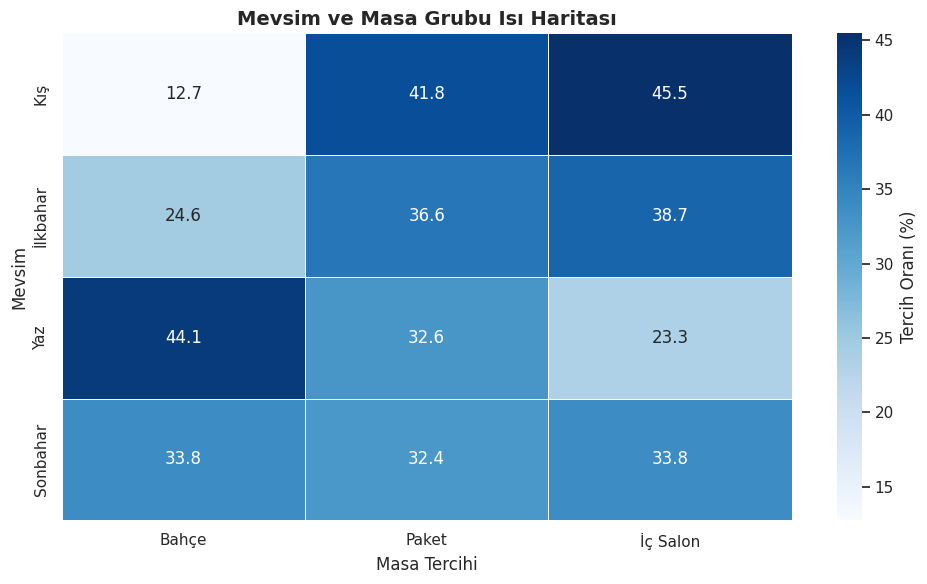

In [35]:
# Mevsim sırasını rapora göre ayarlayalım
mevsim_sirasi = ['Kış', 'İlkbahar', 'Yaz', 'Sonbahar']
if df['mevsim'].dtype.name != 'category':
    df['mevsim'] = pd.Categorical(df['mevsim'], categories=mevsim_sirasi, ordered=True)

# Çapraz tablo (crosstab) oluşturma ve satır bazında yüzdeye çevirme
mevsim_masa_matrisi = pd.crosstab(df['mevsim'], df['masa_grup'], normalize='index') * 100

# Isı haritasını (Heatmap) çizdirme
plt.figure(figsize=(10, 6))
sns.heatmap(mevsim_masa_matrisi,
            annot=True,          # Hücrelerin içine sayıları yaz
            fmt=".1f",           # Tek ondalık basamak göster
            cmap="Blues",        # Renk paleti (Mavi tonları)
            linewidths=.5,       # Hücreler arası çizgiler
            cbar_kws={'label': 'Tercih Oranı (%)'})

plt.title('Mevsim ve Masa Grubu Isı Haritası', fontsize=14, fontweight='bold')
plt.ylabel('Mevsim', fontsize=12)
plt.xlabel('Masa Tercihi', fontsize=12)
plt.tight_layout()
plt.show()

In [37]:
# Yağış Dağılımı Tablosu
yagis_dagilimi = df['yagis_kategori'].value_counts(normalize=True).reset_index()
yagis_dagilimi.columns = ['Yağış Kategorisi', 'Oran (%)']
yagis_dagilimi['Oran (%)'] = (yagis_dagilimi['Oran (%)'] * 100).round(1)

# Sıcaklık Dağılımı Tablosu
sicaklik_dagilimi = df['sicaklik_aralik'].value_counts(normalize=True).reset_index()
sicaklik_dagilimi.columns = ['Sıcaklık Aralığı', 'Oran (%)']
sicaklik_dagilimi['Oran (%)'] = (sicaklik_dagilimi['Oran (%)'] * 100).round(1)

print("--- 2.2 Değişken Yapısı: Yağış Kategorisi ---")
print(yagis_dagilimi.to_string(index=False))
print("\n--------------------------------------------\n")
print("--- 2.2 Değişken Yapısı: Sıcaklık Kategorisi ---")
print(sicaklik_dagilimi.to_string(index=False))

--- 2.2 Değişken Yapısı: Yağış Kategorisi ---
Yağış Kategorisi  Oran (%)
            Açık      54.0
         Bulutlu      29.1
          Yağmur      15.9
             Kar       0.9
         Sağanak       0.1
       Yoğun Kar       0.0

--------------------------------------------

--- 2.2 Değişken Yapısı: Sıcaklık Kategorisi ---
Sıcaklık Aralığı  Oran (%)
   Ilık (10–20°)      39.5
  Sıcak (20–30°)      34.4
   Soğuk (0–10°)      21.5
Çok Sıcak (>30°)       4.3
 Çok Soğuk (<0°)       0.3


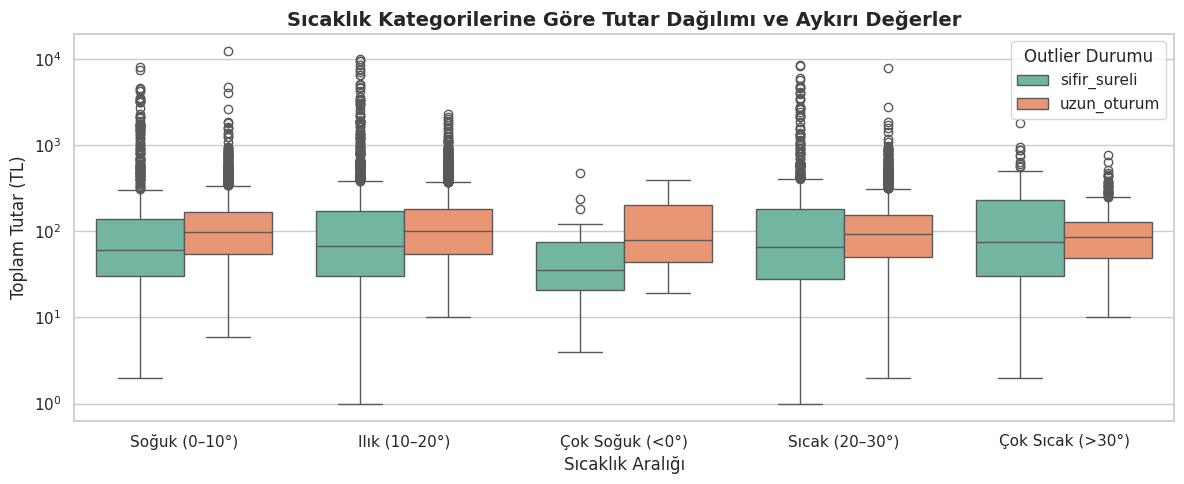

In [39]:
plt.figure(figsize=(12, 5))

# Sıcaklık kategorilerine göre tutar dağılımı (Kruskal-Wallis'in görsel kanıtı)
sns.boxplot(x='sicaklik_aralik', y='toplam_tutar', data=df,
            hue='outlier_flag', palette='Set2')

plt.title('Sıcaklık Kategorilerine Göre Tutar Dağılımı ve Aykırı Değerler', fontsize=14, fontweight='bold')
plt.ylabel('Toplam Tutar (TL)', fontsize=12)
plt.xlabel('Sıcaklık Aralığı', fontsize=12)
plt.yscale('log') # Veriler çok sağ kuyruklu olduğu için logaritmik eksen daha net gösterir
plt.legend(title='Outlier Durumu')
plt.tight_layout()
plt.show()

--- 1. İSTATİSTİKSEL KARAR MATRİSİ ---
            Hipotez       Test Adı Etki Büyüklüğü/H                Karar
   H1: Yağış & Masa        Ki-Kare    ~0.09 (Küçük)              Anlamlı
H2: Sıcaklık & Masa        Ki-Kare     ~0.23 (Orta) Anlamlı (Ana Sürücü)
   H3: Hava & Tutar Kruskal-Wallis    ~579 (Yüksek)              Anlamlı


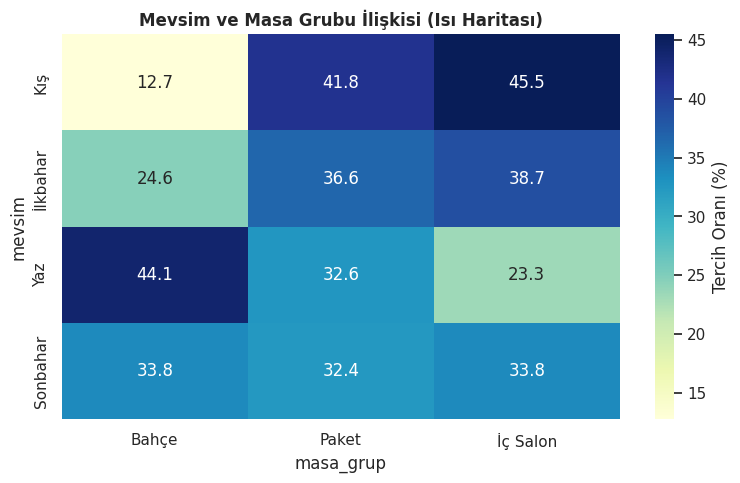

/tmp/ipykernel_3480/2750873142.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sicaklik_aralik', y='toplam_tutar', data=df[df['outlier_flag'].fillna(False) == False], palette='coolwarm')


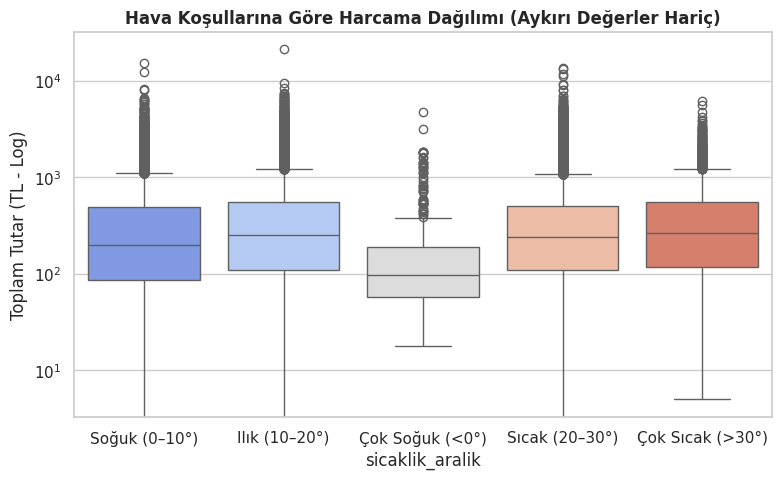


--- 2. OPERASYONEL ÖZET (Yaz Paradoksu Kanıtı) ---
          Ort_Tutar  Bahce_Kullanim_Orani
mevsim                                   
Kış           399.6                  12.7
İlkbahar      462.8                  24.6
Yaz           342.9                  44.1
Sonbahar      368.2                  33.8


In [44]:
# --- FİNAL ANALİZ ÖZETİ VE GÖRSELLEŞTİRME ---

# 1. ÖZET TABLO: Hipotez Test Matrisi
data_hipotez = {
    'Hipotez': ['H1: Yağış & Masa', 'H2: Sıcaklık & Masa', 'H3: Hava & Tutar'],
    'Test Adı': ['Ki-Kare', 'Ki-Kare', 'Kruskal-Wallis'],
    'Etki Büyüklüğü/H': ['~0.09 (Küçük)', '~0.23 (Orta)', '~579 (Yüksek)'],
    'Karar': ['Anlamlı', 'Anlamlı (Ana Sürücü)', 'Anlamlı']
}
df_hipotez = pd.DataFrame(data_hipotez)

print("--- 1. İSTATİSTİKSEL KARAR MATRİSİ ---")
print(df_hipotez.to_string(index=False))

# 2. GÖRSEL: Mevsim x Masa Grubu (Isı Haritası)
# Raporun görsel hiyerarşisi için
plt.figure(figsize=(9, 5))
mevsim_masa_matrisi = pd.crosstab(df['mevsim'], df['masa_grup'], normalize='index') * 100
sns.heatmap(mevsim_masa_matrisi, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Tercih Oranı (%)'})
plt.title('Mevsim ve Masa Grubu İlişkisi (Isı Haritası)', fontweight='bold')
plt.show()

# 3. GÖRSEL: Tutar Dağılımı (Kruskal-Wallis Doğrulaması)
plt.figure(figsize=(9, 5))
sns.boxplot(x='sicaklik_aralik', y='toplam_tutar', data=df[df['outlier_flag'].fillna(False) == False], palette='coolwarm')
plt.title('Hava Koşullarına Göre Harcama Dağılımı (Aykırı Değerler Hariç)', fontweight='bold')
plt.yscale('log') # Dağılımı daha net görmek için logaritmik ölçek
plt.ylabel('Toplam Tutar (TL - Log)')
plt.show()

# 4. OPERASYONEL ÖZET: Yaz Paradoksu Verisi
ozet_metrikler = df.groupby('mevsim', observed=True).agg(
    Ort_Tutar=('toplam_tutar', 'mean'),
    Bahce_Kullanim_Orani=('masa_grup', lambda x: (x == 'Bahçe').mean() * 100)
).round(1)

print("\n--- 2. OPERASYONEL ÖZET (Yaz Paradoksu Kanıtı) ---")
print(ozet_metrikler)

# İPUCU: Görselleri kaydetmek istersen:
# plt.savefig('ozet_grafik.png', dpi=300)
